# Isolated Model Analysis: LOGISTIC_REGRESSION

This notebook is dedicated entirely to deeply analyzing the logistic_regression classification model (The 'Intelligent Fire Alarm'). It generates 9 highly specific diagnostic graphs to prove the alarm triggers exactly when it should without crying wolf.

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
# Assuming execution from within classification_project/models/
DATA_PATH = os.path.join("..", "..", "data", "raw", "AE_DATA_with_AvgEGT.csv")
df = pd.read_csv(DATA_PATH).drop_duplicates().dropna()

if 'AvgEGT' in df.columns:
    df = df[df['AvgEGT'] <= 1000]

# 2. Exclude Features
excluded_cols = [
    "EXHAUST TEMP 1", "EXHAUST TEMP 2", "EXHAUST TEMP 3", 
    "EXHAUST TEMP 4", "EXHAUST TEMP 5", "EXHAUST TEMP 6",
    "FREQ", "AMP", "CPW IN TEMP", "CPW OUT TEMP"
]
drop_cols = [c for c in excluded_cols if c in df.columns]
df = df.drop(columns=drop_cols)

# 3. Transform to Binary Classification (Top 10% Critical Risk)
threshold = np.percentile(df['AvgEGT'], 90)
df['Risk_Class'] = (df['AvgEGT'] >= threshold).astype(int)

X = df.drop(columns=['AvgEGT', 'Risk_Class'])
y = df['Risk_Class']

# 4. Split & Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression

# 5. Initialize Model
model = LogisticRegression(random_state=42, class_weight='balanced')

# 6. Train and Evaluate

model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

print("--- Model Results ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Critical"]))


--- Model Results ---
Accuracy Score: 86.81%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.87      0.92        82
    Critical       0.42      0.89      0.57         9

    accuracy                           0.87        91
   macro avg       0.70      0.88      0.75        91
weighted avg       0.93      0.87      0.89        91



In [2]:
model_name = 'logistic_regression'
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, brier_score_loss
from sklearn.calibration import calibration_curve

In [3]:
try:
    y_prob = model.predict_proba(X_test_s)[:, 1]
except:
    if hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test_s)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())
    else:
        y_prob = y_pred

### 1. Raw Confusion Matrix (Heatmap)
**(Use: Exact Failure Count)** A grid showing exactly how many times the AI was perfectly correct vs. how many False Alarms or Missed Dangers occurred.

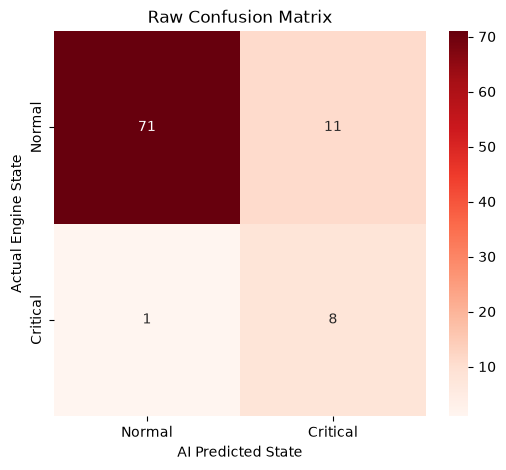

In [4]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Normal', 'Critical'], yticklabels=['Normal', 'Critical'])
plt.ylabel('Actual Engine State')
plt.xlabel('AI Predicted State')
plt.title('Raw Confusion Matrix')
plt.show()

### 2. Normalized Confusion Matrix (Percentages)
**(Use: Contextual Failure Rate)** The same grid, but displayed as percentages so you can see what *percent* of total failures were successfully caught.

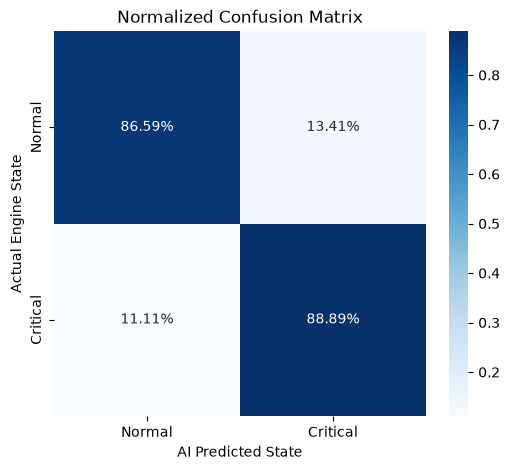

In [5]:
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=['Normal', 'Critical'], yticklabels=['Normal', 'Critical'])
plt.ylabel('Actual Engine State')
plt.xlabel('AI Predicted State')
plt.title('Normalized Confusion Matrix')
plt.show()

### 3. ROC Curve
**(Use: Scientific Proof)** Proves the AI is not just randomly guessing. The more the blue line pulls toward the top-left corner, the smarter the AI is.

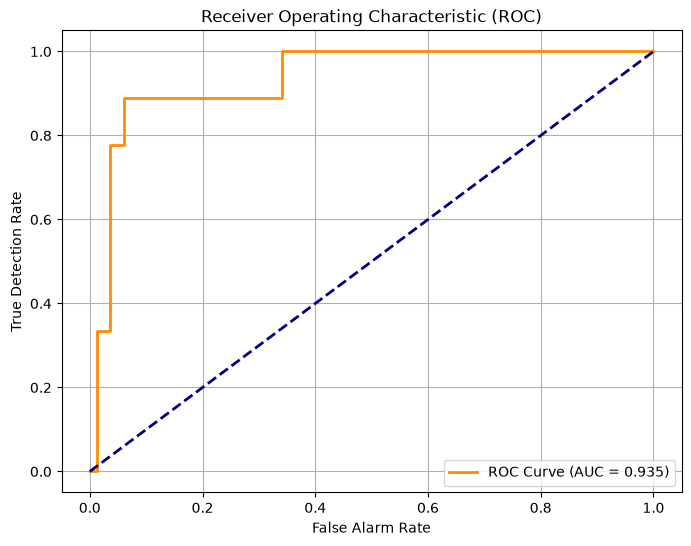

In [6]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Alarm Rate')
plt.ylabel('True Detection Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### 4. Precision-Recall Curve
**(Use: Alarm Trust)** Proves that when the alarm rings, it is a real failure (Precision), and proves it catches almost all failures (Recall).

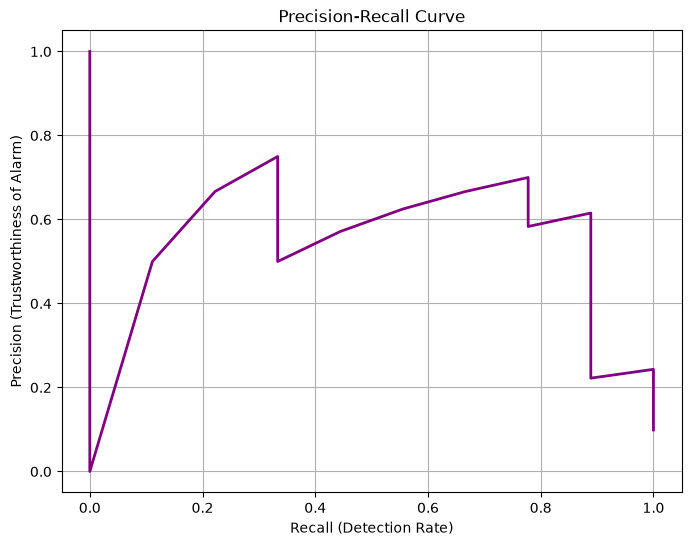

In [7]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(8,6))
plt.plot(recall, precision, color='purple', lw=2)
plt.xlabel('Recall (Detection Rate)')
plt.ylabel('Precision (Trustworthiness of Alarm)')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

### 5. Class Probability Distribution
**(Use: Confidence Check)** Shows how confident the AI is. Does it sit on the fence at 50%, or is it highly confident near 0% (Normal) and 100% (Critical)?

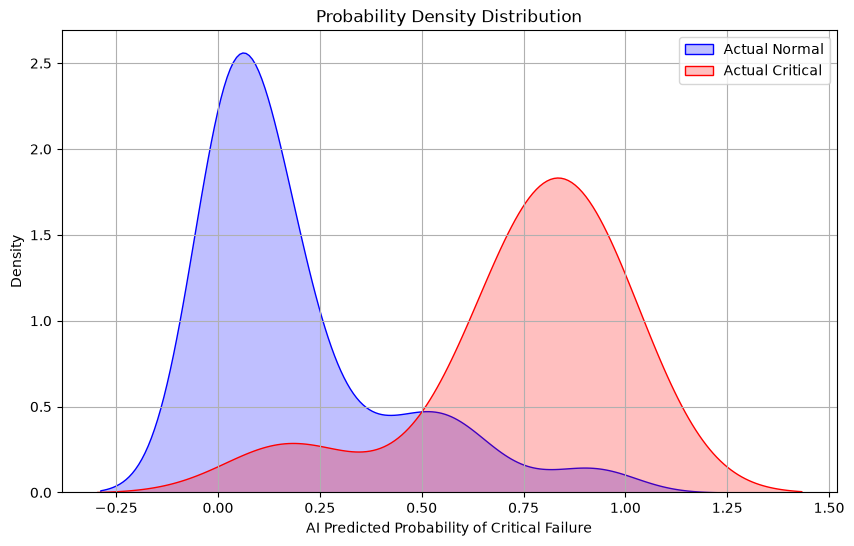

In [8]:
plt.figure(figsize=(10,6))
sns.kdeplot(y_prob[y_test==0], label='Actual Normal', shade=True, color='blue')
sns.kdeplot(y_prob[y_test==1], label='Actual Critical', shade=True, color='red')
plt.xlabel('AI Predicted Probability of Critical Failure')
plt.title('Probability Density Distribution')
plt.legend()
plt.grid(True)
plt.show()

### 6. Calibration Curve (Reliability)
**(Use: Trusting the AI's Output)** If the AI says '80% chance of failure', is it actually right 80% of the time? This graph proves it.

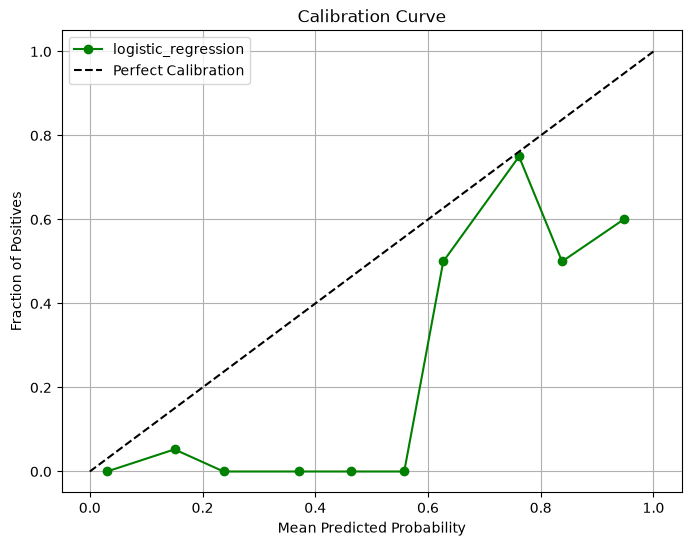

In [9]:
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
plt.figure(figsize=(8,6))
plt.plot(prob_pred, prob_true, marker='o', color='green', label=model_name)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)
plt.show()

### 7 & 8. Cumulative Gains and Lift Curve
**(Use: Business Value Proof)** Shows exactly how many times faster you catch a failure using this AI versus randomly checking engines by hand.

In [10]:
try:
    import scikitplot as skplt
    # Skplt requires a 2D array of probabilities [P(class_0), P(class_1)]
    if len(y_prob.shape) == 1:
        y_prob_2d = np.vstack([1-y_prob, y_prob]).T
    else:
        y_prob_2d = y_prob
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    skplt.metrics.plot_cumulative_gain(y_test, y_prob_2d, ax=ax[0])
    skplt.metrics.plot_lift_curve(y_test, y_prob_2d, ax=ax[1])
    plt.show()
except ImportError:
    print('Please install scikit-plot to view Cumulative Gains and Lift Curves (pip install scikit-plot)')

Please install scikit-plot to view Cumulative Gains and Lift Curves (pip install scikit-plot)


### 9. Feature Importance / Coefficients
**(Use: Maintenance Focus)** Shows exactly which sensors trigger the fire alarm the most for this specific AI model. *(Note: Not all mathematical models support this graph).*

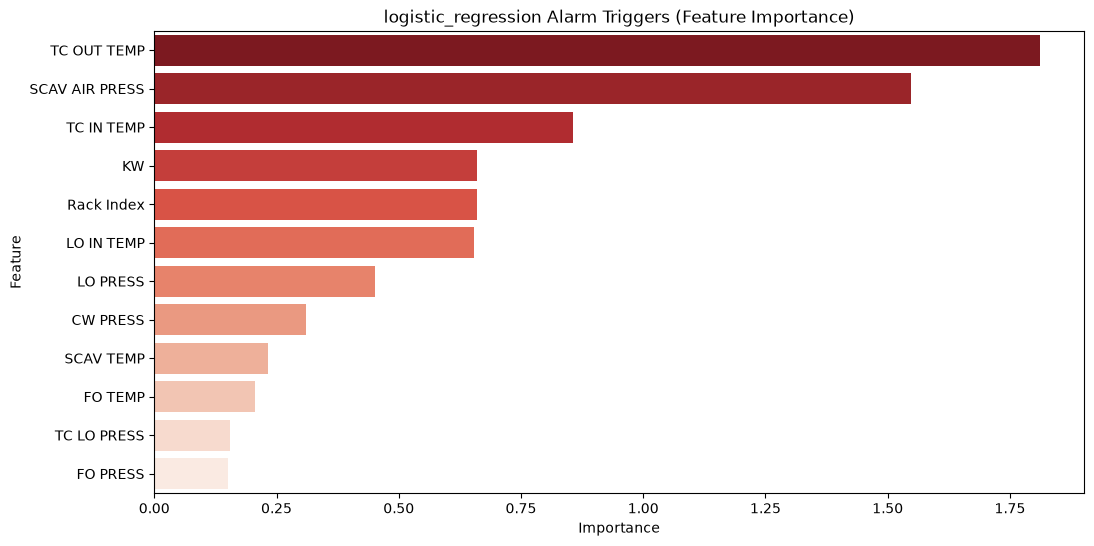

In [11]:
try:
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    elif hasattr(model, 'coef_'):
        imp = np.abs(model.coef_[0])
    else:
        raise ValueError('No feature importances found for this model.')
    
    feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': imp}).sort_values('Importance', ascending=False)
    plt.figure(figsize=(12,6))
    sns.barplot(x='Importance', y='Feature', data=feat_df, palette='Reds_r')
    plt.title(f'{model_name} Alarm Triggers (Feature Importance)')
    plt.show()
except Exception as e:
    print(f'Cannot plot feature importance: {e}')